In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
df = pd.read_excel("proc.xlsx", sheet_name="Sheet1")

In [ ]:
# lets work with a subsample of data to make EDA fast
size = 10_000
df = df.sample(size)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 30692 to 33733
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Age                    10000 non-null  int64 
 1   Gender                 10000 non-null  object
 2   Region                 10000 non-null  object
 3   Marital_status         10000 non-null  object
 4   Number Of Dependants   10000 non-null  int64 
 5   BMI_Category           10000 non-null  object
 6   Smoking_Status         10000 non-null  object
 7   Employment_Status      10000 non-null  object
 8   Income_Level           10000 non-null  object
 9   Income_Lakhs           10000 non-null  int64 
 10  Medical History        10000 non-null  object
 11  Insurance_Plan         10000 non-null  object
 12  Annual_Premium_Amount  10000 non-null  int64 
 13  Diabetes               10000 non-null  int64 
 14  Heart disease          10000 non-null  int64 
 15  High blood pressure 

In [ ]:
cat = list(df.select_dtypes(include=["object"]).columns) #categorical
num = list(df.select_dtypes(exclude=["object"]).columns) #numerical
cat, num

(['Gender',
  'Region',
  'Marital_status',
  'BMI_Category',
  'Smoking_Status',
  'Employment_Status',
  'Income_Level',
  'Medical History',
  'Insurance_Plan'],
 ['Age',
  'Number Of Dependants',
  'Income_Lakhs',
  'Annual_Premium_Amount',
  'Diabetes',
  'Heart disease',
  'High blood pressure',
  'No Disease',
  'Thyroid'])

In [7]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount,Diabetes,Heart disease,High blood pressure,No Disease,Thyroid
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,34.347000,1.733000,22.758600,15801.676200,0.265400,0.089100,0.197400,0.423700,0.119800
std,13.664621,1.503375,22.201955,8406.990725,0.441568,0.284902,0.398057,0.494169,0.324744
min,18.000000,0.000000,1.000000,3502.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,7.000000,8632.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,2.000000,16.000000,14079.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,45.000000,3.000000,31.000000,22307.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,72.000000,5.000000,100.000000,41658.000000,1.000000,1.000000,1.000000,1.000000,1.000000


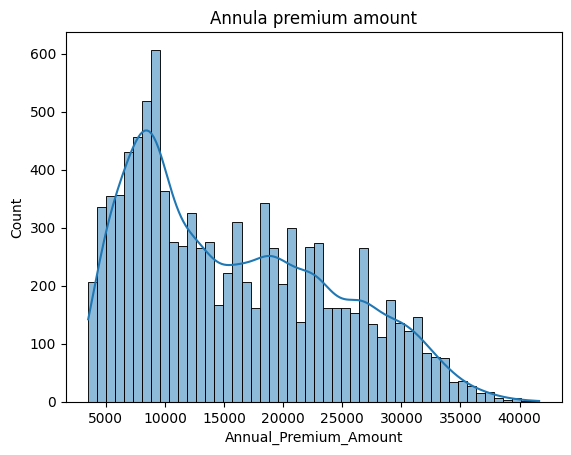

In [8]:
sns.histplot(df['Annual_Premium_Amount'], kde=True, bins = 50)
plt.title("Annula premium amount")
plt.show()

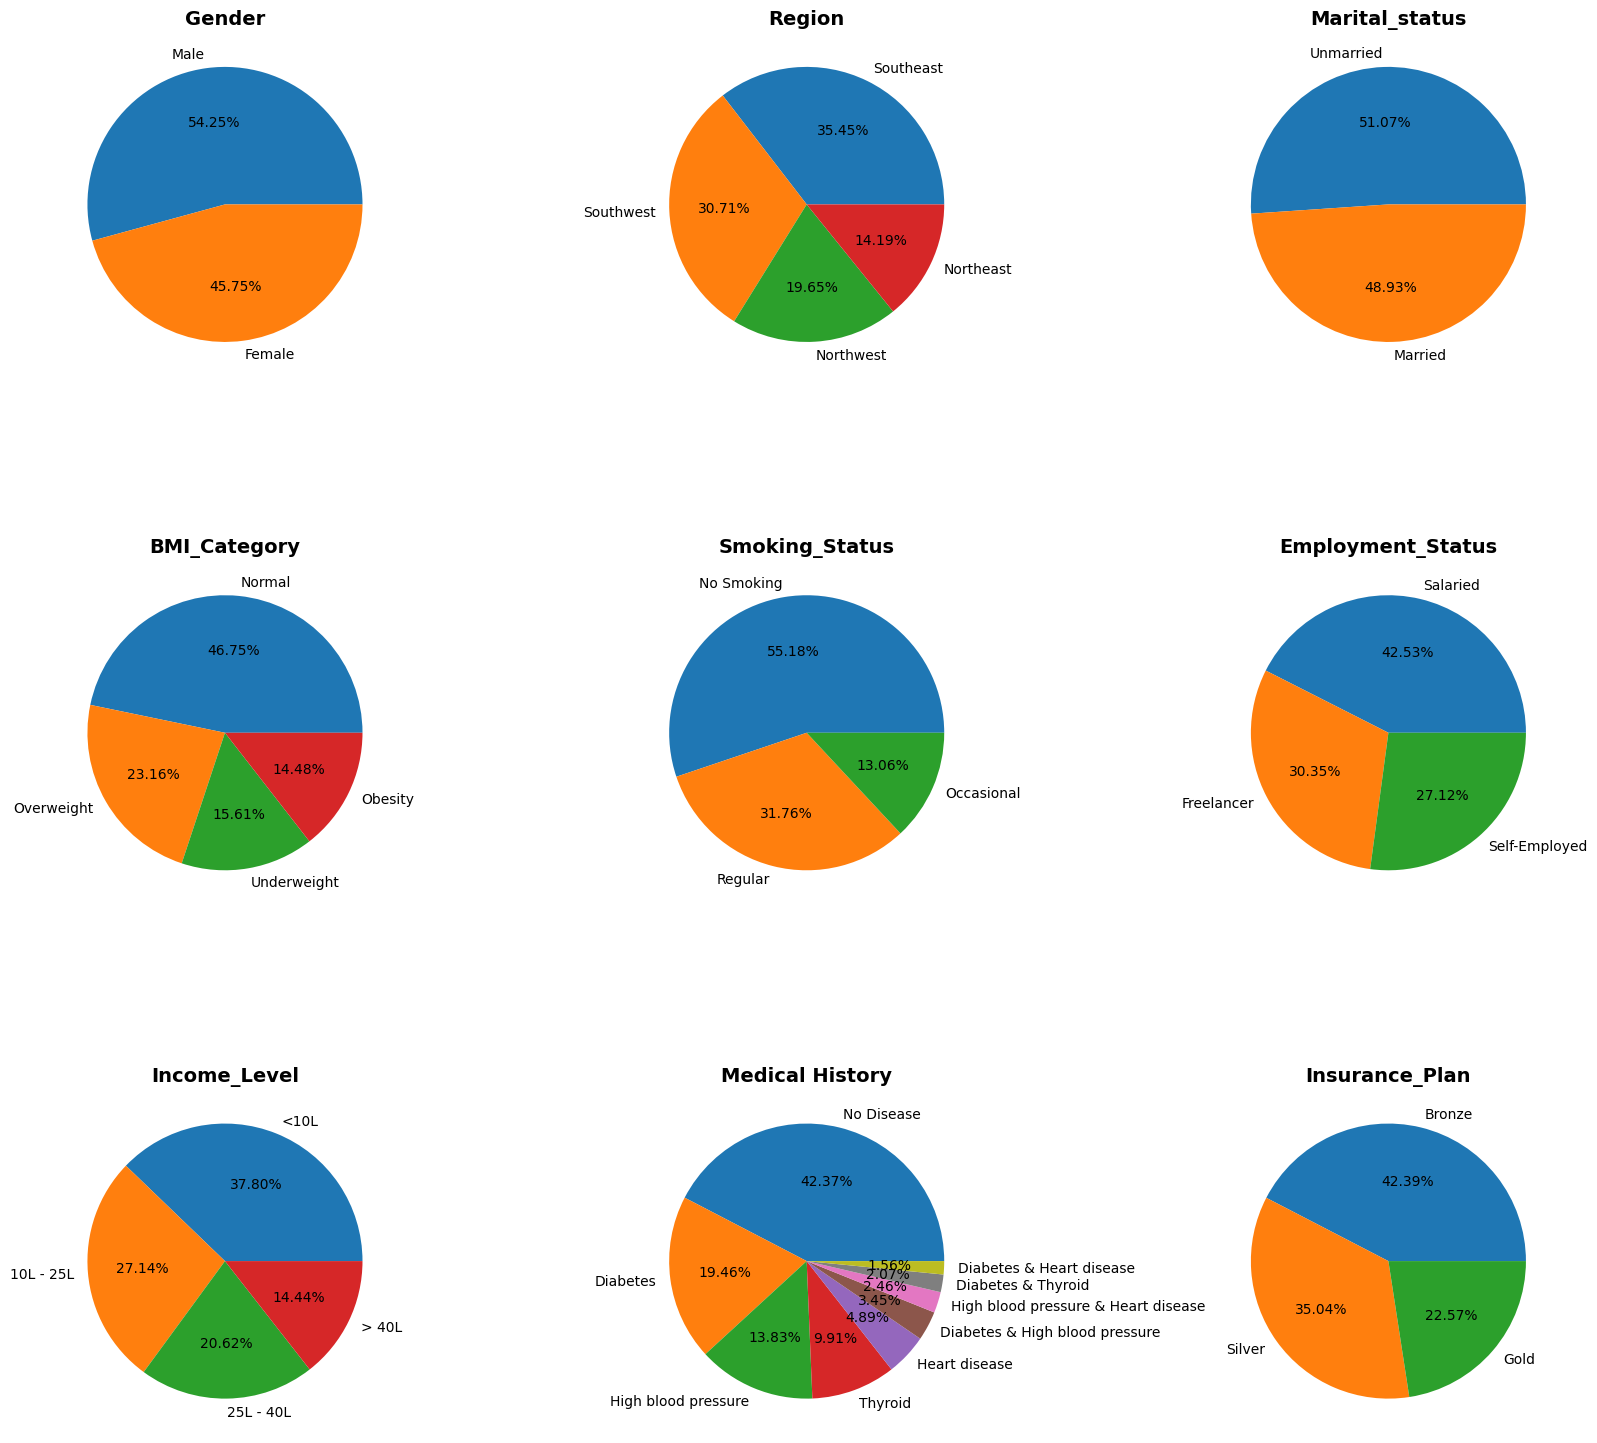

In [9]:
# have a look at categories
k = 1
plt.figure(figsize=(16,16))
for i in cat:
    counts = df[i].value_counts()
    # pct = round((counts/counts.sum())*100, 3)

    # temp_df = pd.DataFrame(columns = ["count", "pct"])
    # temp_df["count"] = counts
    # temp_df["pct"] = pct
    plt.subplot(3,3,k)
    plt.pie(x = counts,autopct="%.2f%%", labels=counts.index)
    plt.title(f"{i}", fontsize=14, fontweight="bold")
    k+=1

plt.tight_layout()
plt.show()

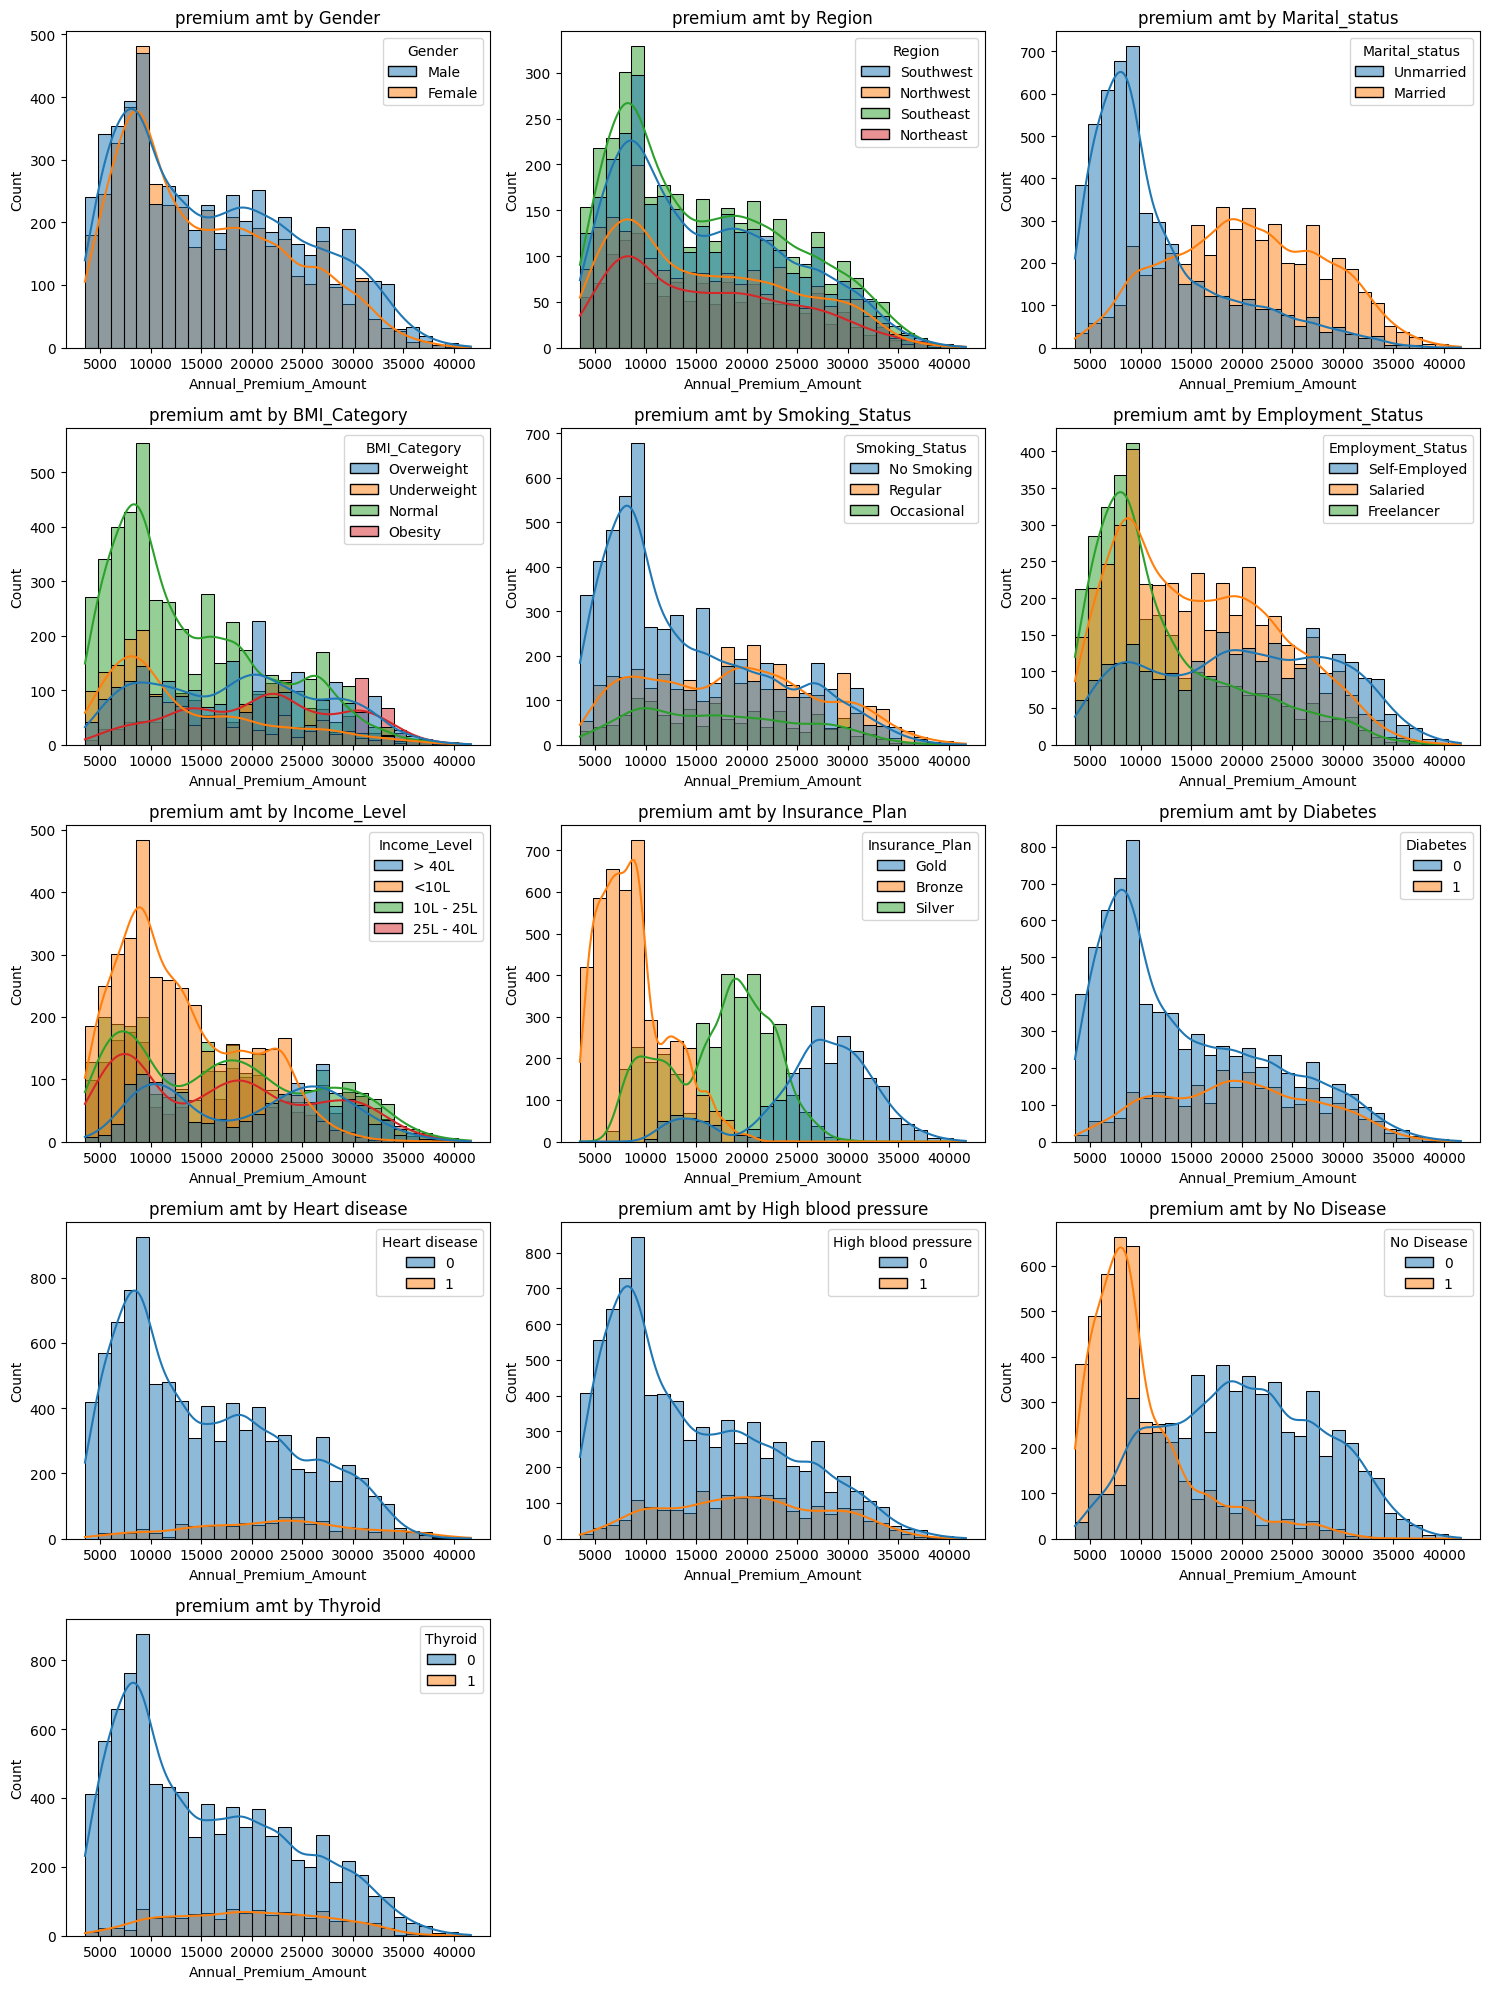

In [10]:
x = [
    'Gender',
    'Region',
    'Marital_status',
    'BMI_Category',
    'Smoking_Status',
    'Employment_Status',
    'Income_Level',
    'Insurance_Plan',
    'Diabetes',
    'Heart disease',
    'High blood pressure',
    'No Disease',
    'Thyroid'
]
k = 1
plt.figure(figsize=(15,20))
for i in x:
    plt.subplot(5,3, k)
    sns.histplot(data = df, x = 'Annual_Premium_Amount', hue = i, kde=True, bins = 30)
    plt.title(f"premium amt by {i}")
    k+=1
plt.tight_layout()    
plt.show()  

verdict:

- features like martial statuts, insurance plan, disease status, BMI heavily influences permium price.

- other features like smoking status, income level also has some impact on permium price.

- as expected, the premium price is less affected by gender and region.

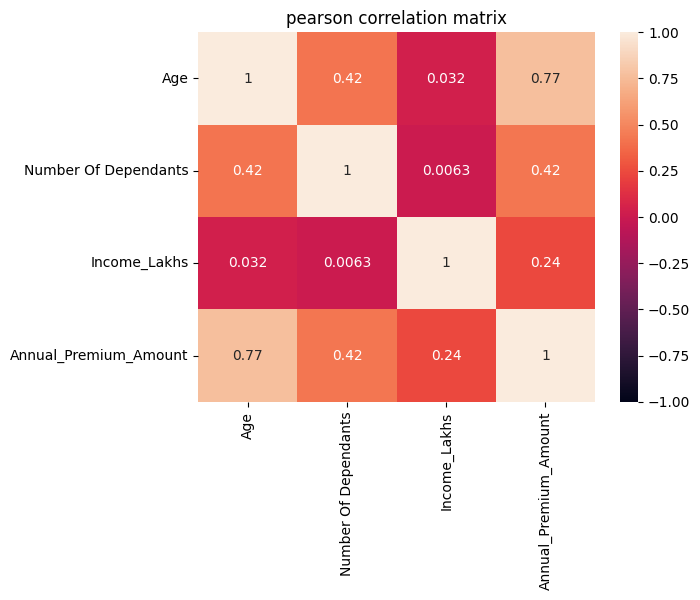

In [11]:
x = ['Age',
 'Number Of Dependants',
 'Income_Lakhs',
 'Annual_Premium_Amount']

sns.heatmap(df[x].corr(), annot=True, vmin=-1, vmax = 1)
plt.title("pearson correlation matrix")
plt.show()

target is highly correlated with Age and NOD,
and slightly with income 

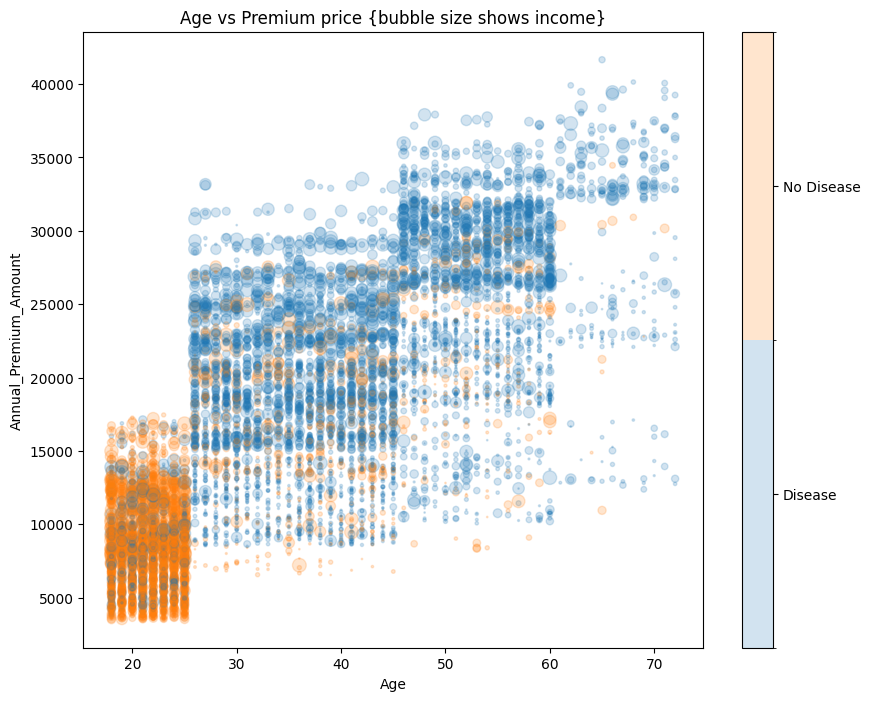

In [12]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

disease = df["No Disease"].astype(int)

ax = df.plot(
    kind="scatter",
    x="Age",
    y="Annual_Premium_Amount",
    alpha=0.2,
    s=df["Income_Lakhs"],
    figsize=(10, 8),
    c=disease,
    cmap="tab10",
    norm=mcolors.BoundaryNorm([-0.5, 0.5, 1.5], 2),
    colorbar=True
)

cbar = ax.collections[0].colorbar
cbar.set_ticks([0, 1])
cbar.set_ticklabels(["Disease", "No Disease"])
ax.set_title("Age vs Premium price {bubble size shows income}")
plt.show()

from this graph:

- premium price tend to increase with age.

- also high income (large bubble size) people generally have expensive premium plans.

- majority of people who dont have disease are under age of 25, this can be verified from below graph

Text(0.5, 1.0, 'Age distribution')

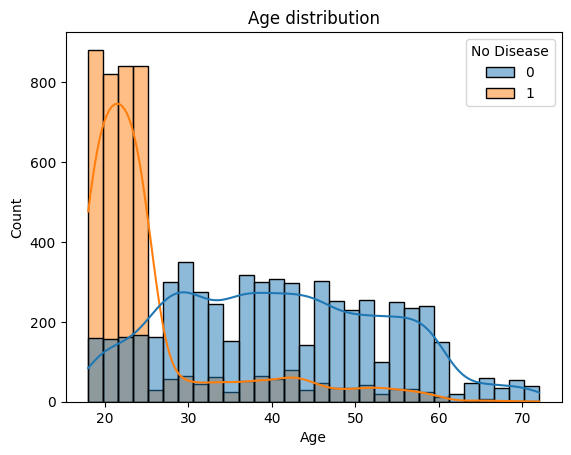

In [13]:
sns.histplot(data = df, x = 'Age', hue = "No Disease", kde=True, bins = 30)
plt.title(f"Age distribution")

In [ ]:
# now let's try to find why married people have more premium price ?

# is it becuause of NOD?
df.groupby("Marital_status").agg({"Number Of Dependants": 'median'}).rename({"Number Of Dependants": "median NOD"}, axis = 1)

,median NOD
Marital_status,
Married,3.0
Unmarried,0.0


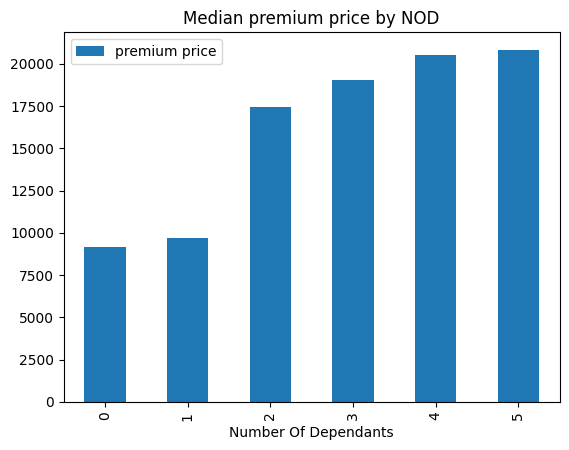

In [15]:
temp = df.groupby("Number Of Dependants").agg({"Annual_Premium_Amount": 'median'})
temp.rename({"Annual_Premium_Amount": "premium price"}, axis = 1).plot(kind = 'bar')
plt.title("Median premium price by NOD")
plt.show()

high NOD will tend to have high price, which was evident from the correlation matrix also

In [18]:
# we saw before, that the insurance plan is an important variable for out target
# let's whos buying what

In [25]:
pd.crosstab(df['Income_Level'], df['Insurance_Plan'], margins=True, normalize='index')

Insurance_Plan,Bronze,Gold,Silver
Income_Level,,,
10L - 25L,0.364407,0.275608,0.359985
25L - 40L,0.361785,0.274006,0.364210
<10L,0.632011,0.051852,0.316138
> 40L,0.079640,0.518006,0.402355
All,0.423900,0.225700,0.350400


In [46]:
counts = pd.crosstab(df['Income_Level'], df['Insurance_Plan'])
counts

Insurance_Plan,Bronze,Gold,Silver
Income_Level,,,
10L - 25L,989,748,977
25L - 40L,746,565,751
<10L,2389,196,1195
> 40L,115,748,581


In [47]:
counts.iloc[0]

Insurance_Plan
Bronze    989
Gold      748
Silver    977
Name: 10L - 25L, dtype: int64

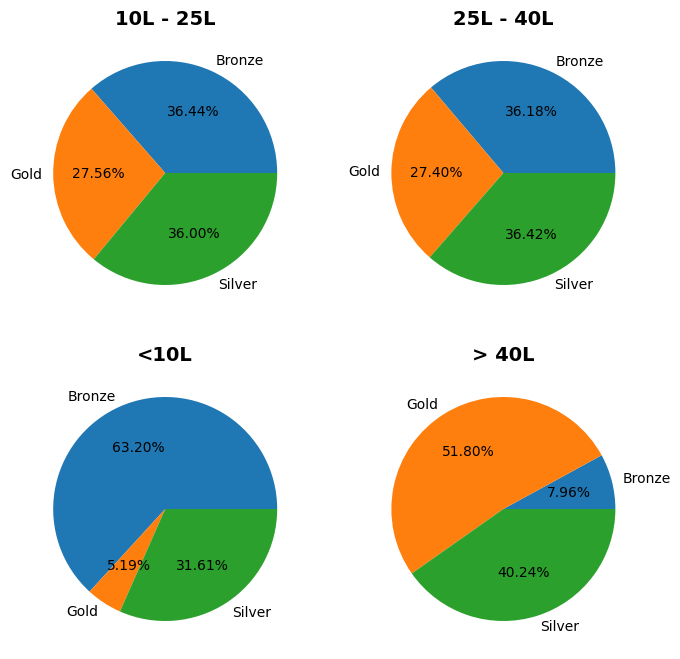

In [55]:
plt.figure(figsize = (8,8))
for i in range(4):
    plt.subplot(2,2,i+1)
    ser = counts.iloc[i]
    plt.pie(x = ser,autopct="%.2f%%", labels=ser.index)
    plt.title(f"{ser.name}", fontsize=14, fontweight="bold")